<a href="https://colab.research.google.com/github/FatiBuuloloo/MLOps_Data_Drift_Monitoring_for_Calorie_Prediction-mini_project-013/blob/main/calorie_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import learning_curve

In [2]:
url = "https://raw.githubusercontent.com/FatiBuuloloo/MLOps_Data_Drift_Monitoring_for_Calorie_Prediction-mini_project-013/main/Dataset/calories.csv"

data = pd.read_csv(url)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [3]:
data.drop("User_ID",axis=1,inplace=True)
data.describe()

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


<Axes: >

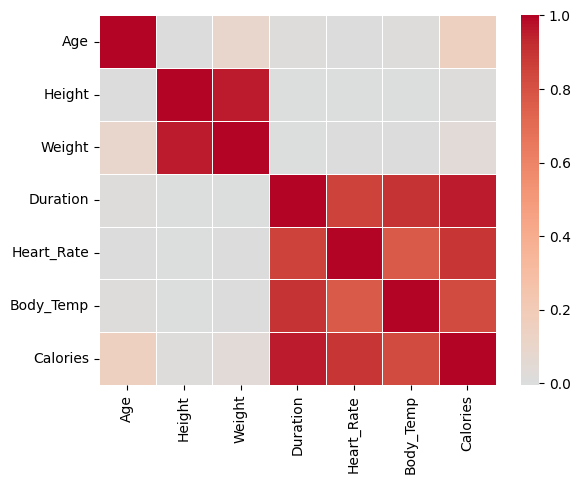

In [4]:
num_cols = data.select_dtypes(include=['number']).columns
corr_matrix = data[num_cols].corr(numeric_only=True)
sns.heatmap(
    corr_matrix,
    annot=False,
    mask=None,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar=True
)

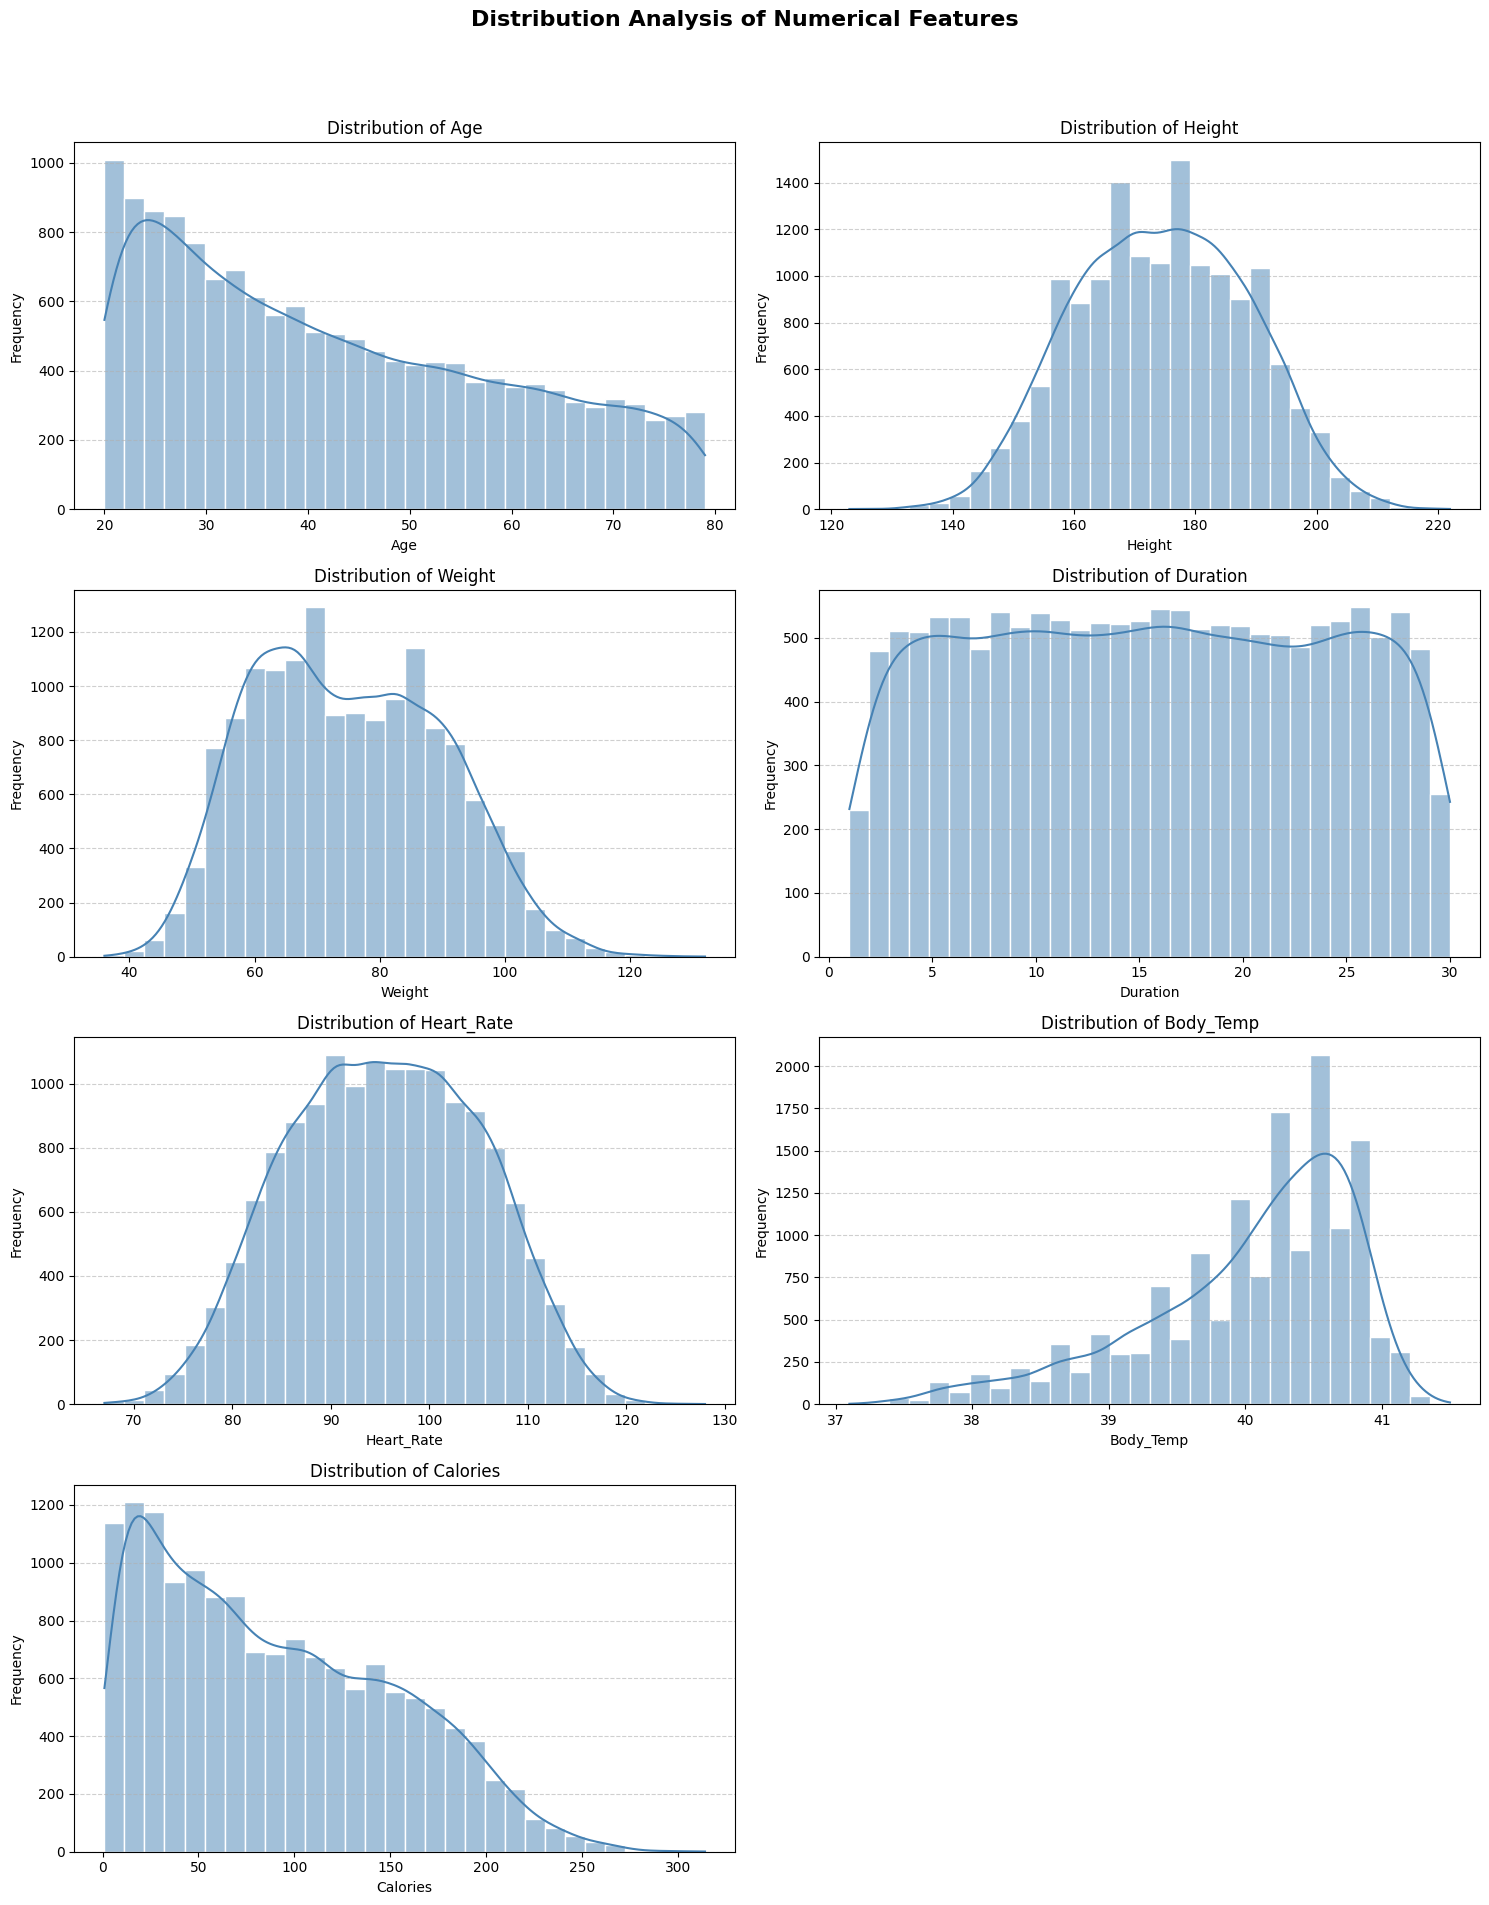

In [5]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
fig.suptitle('Distribution Analysis of Numerical Features', fontsize=16, fontweight='bold')

axes = axes.flatten()

for i, item in enumerate(num_cols):
    sns.histplot(data[item], kde=True, color='steelblue', bins=30, ax=axes[i], edgecolor='white')
    axes[i].set_title(f'Distribution of {item}', fontsize=12)
    axes[i].set_xlabel(item)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

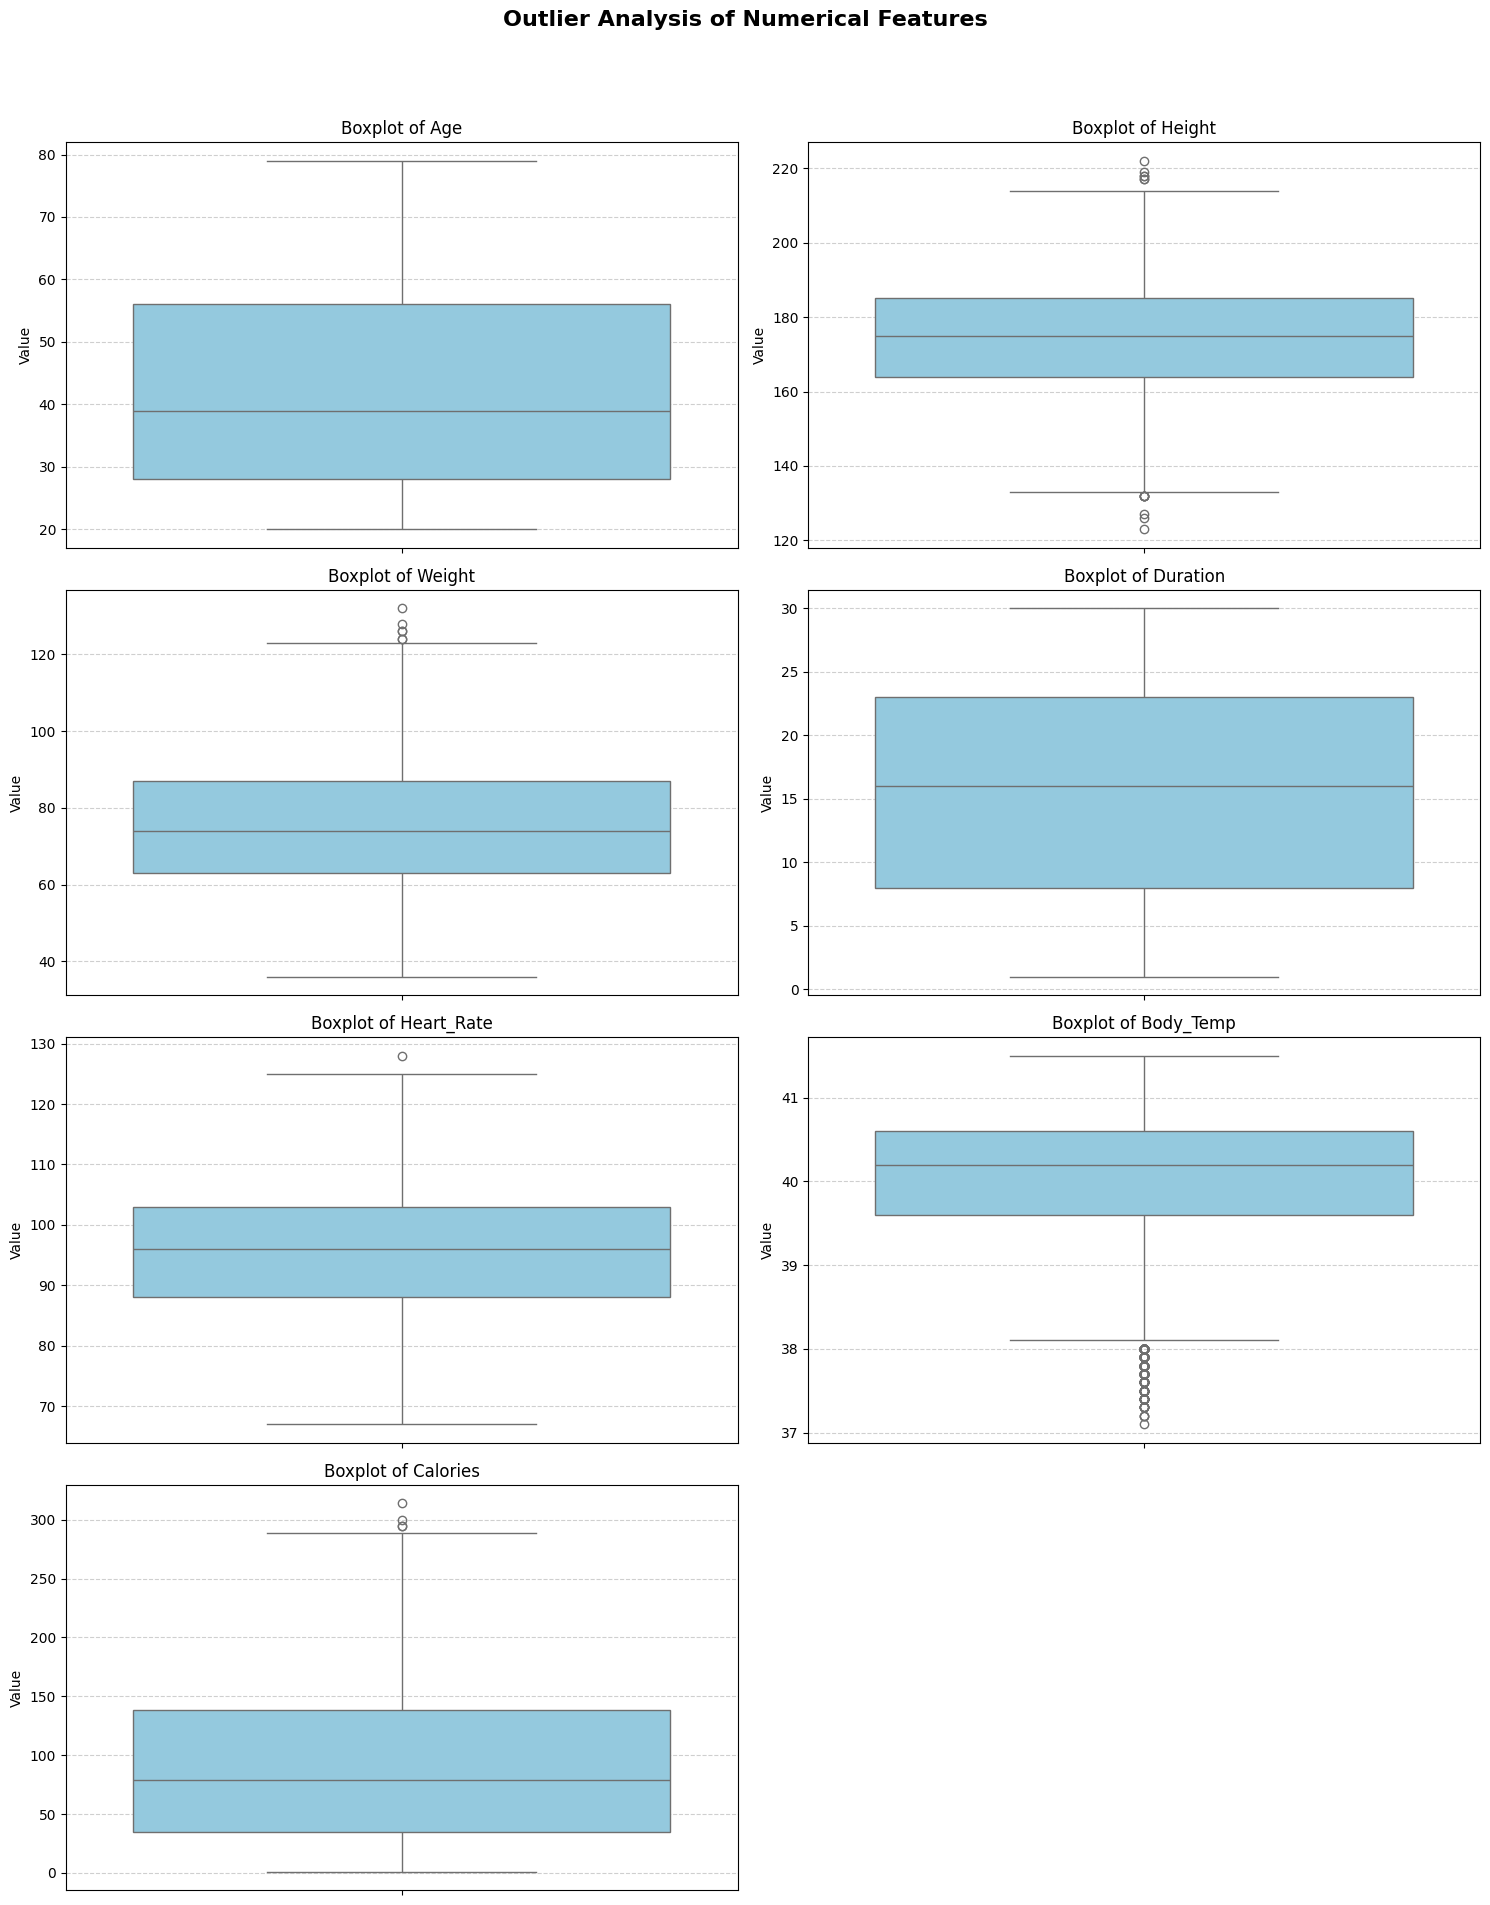

In [6]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
fig.suptitle('Outlier Analysis of Numerical Features', fontsize=16, fontweight='bold')

axes = axes.flatten()

for i, item in enumerate(num_cols):
    sns.boxplot(y=data[item], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {item}', fontsize=12)
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Box-Cox transformation

In [14]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='box-cox', standardize=True)
data_bc = pt.fit_transform(data[num_cols])
data_bc = pd.DataFrame(data_bc, columns=num_cols)

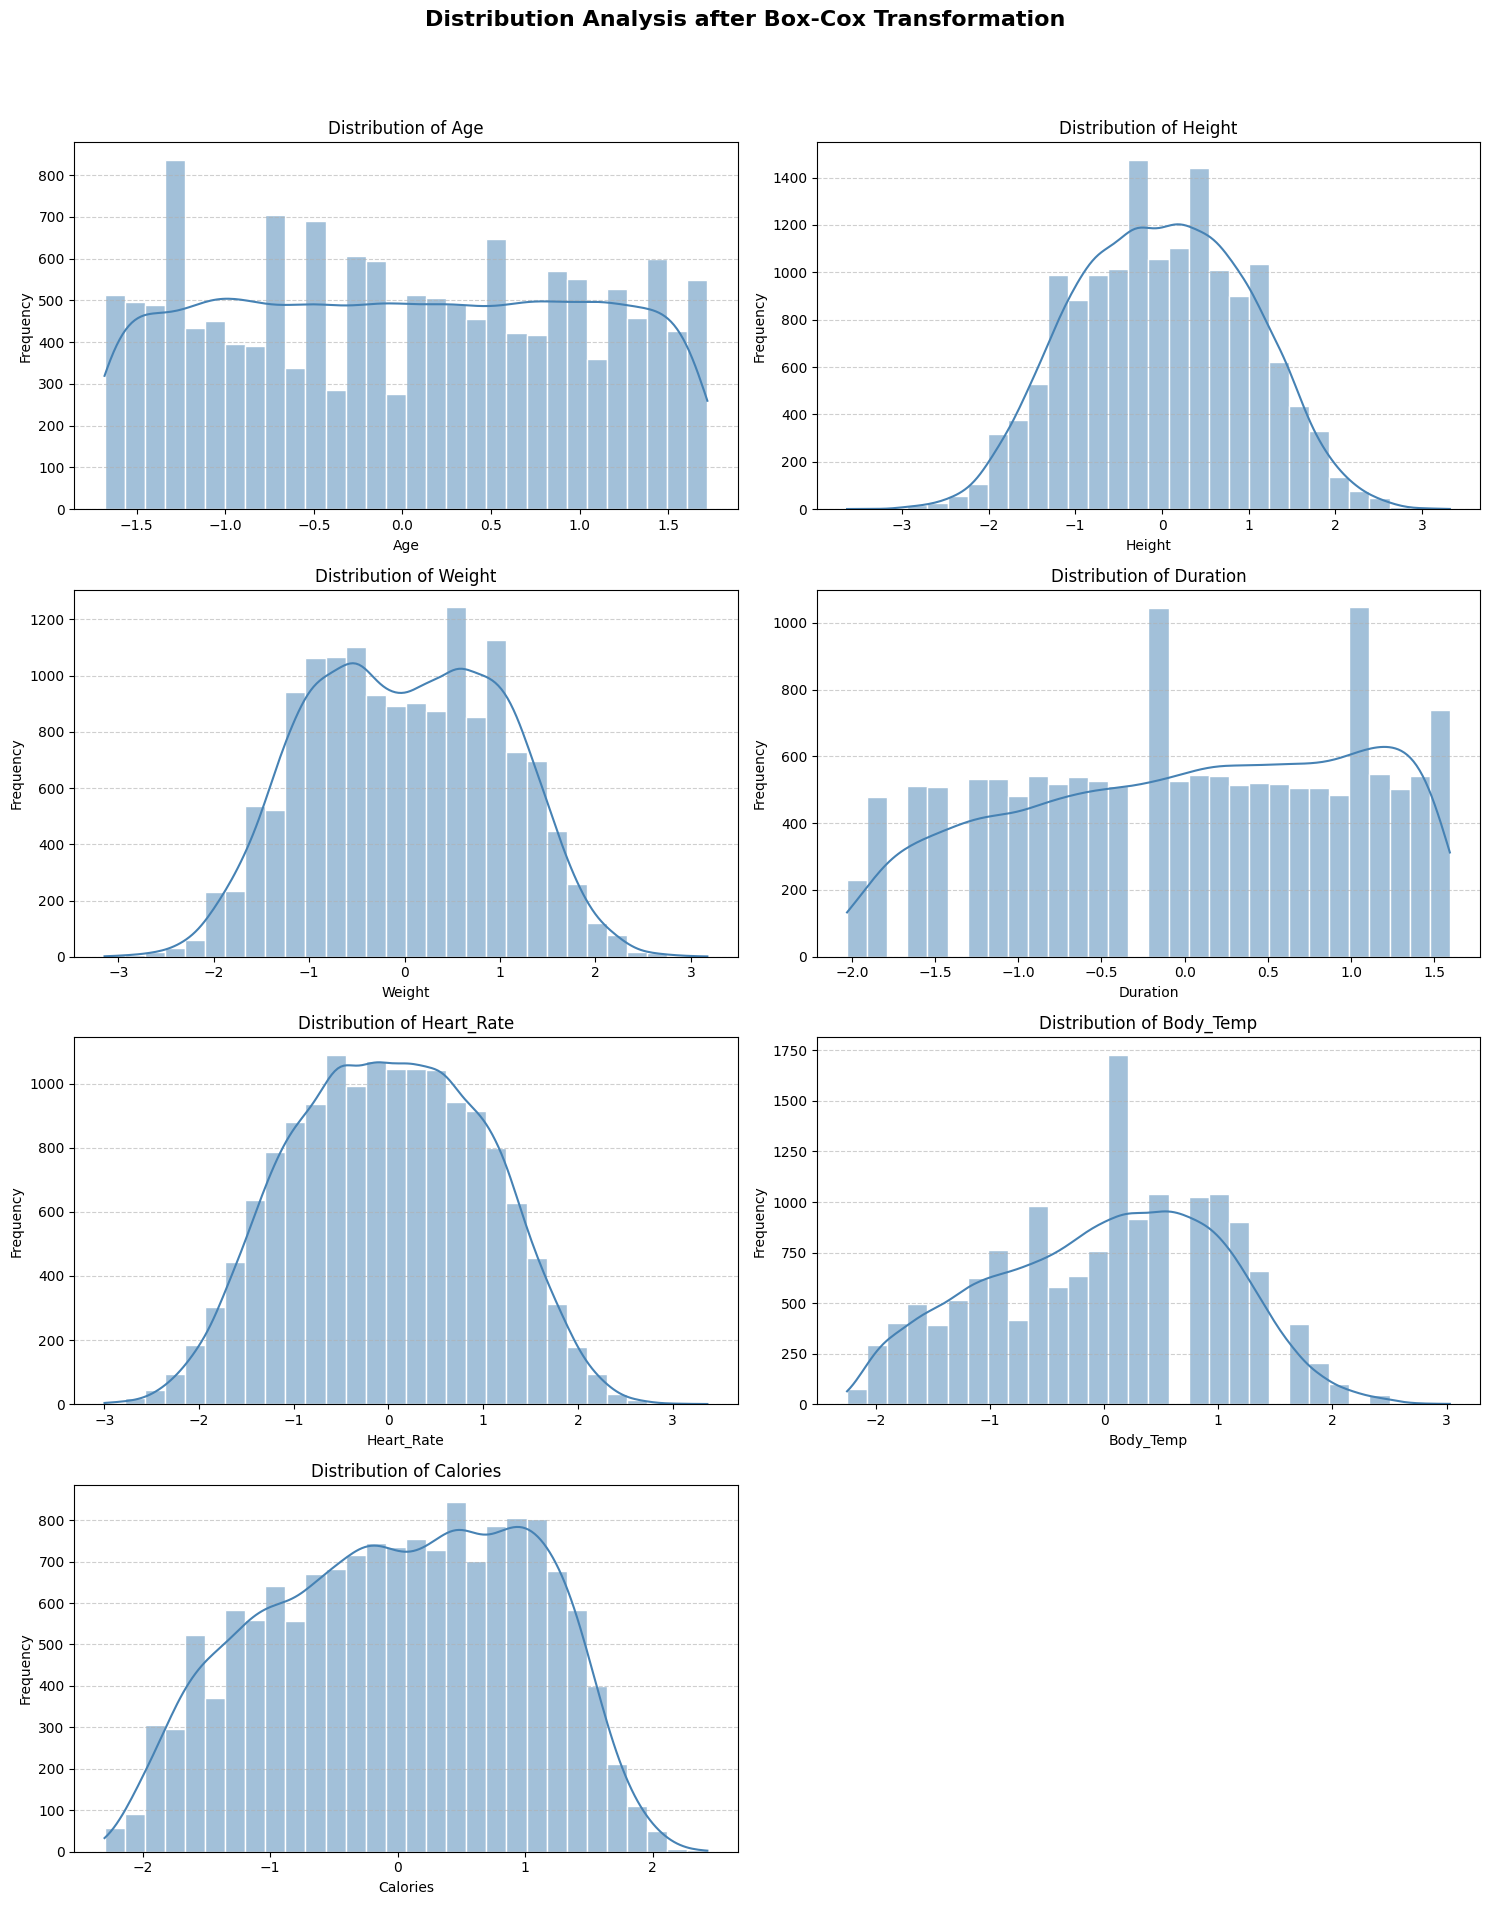

In [15]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
fig.suptitle('Distribution Analysis after Box-Cox Transformation', fontsize=16, fontweight='bold')

axes = axes.flatten()

for i, item in enumerate(num_cols):
    sns.histplot(data_bc[item], kde=True, color='steelblue', bins=30, ax=axes[i], edgecolor='white')
    axes[i].set_title(f'Distribution of {item}', fontsize=12)
    axes[i].set_xlabel(item)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

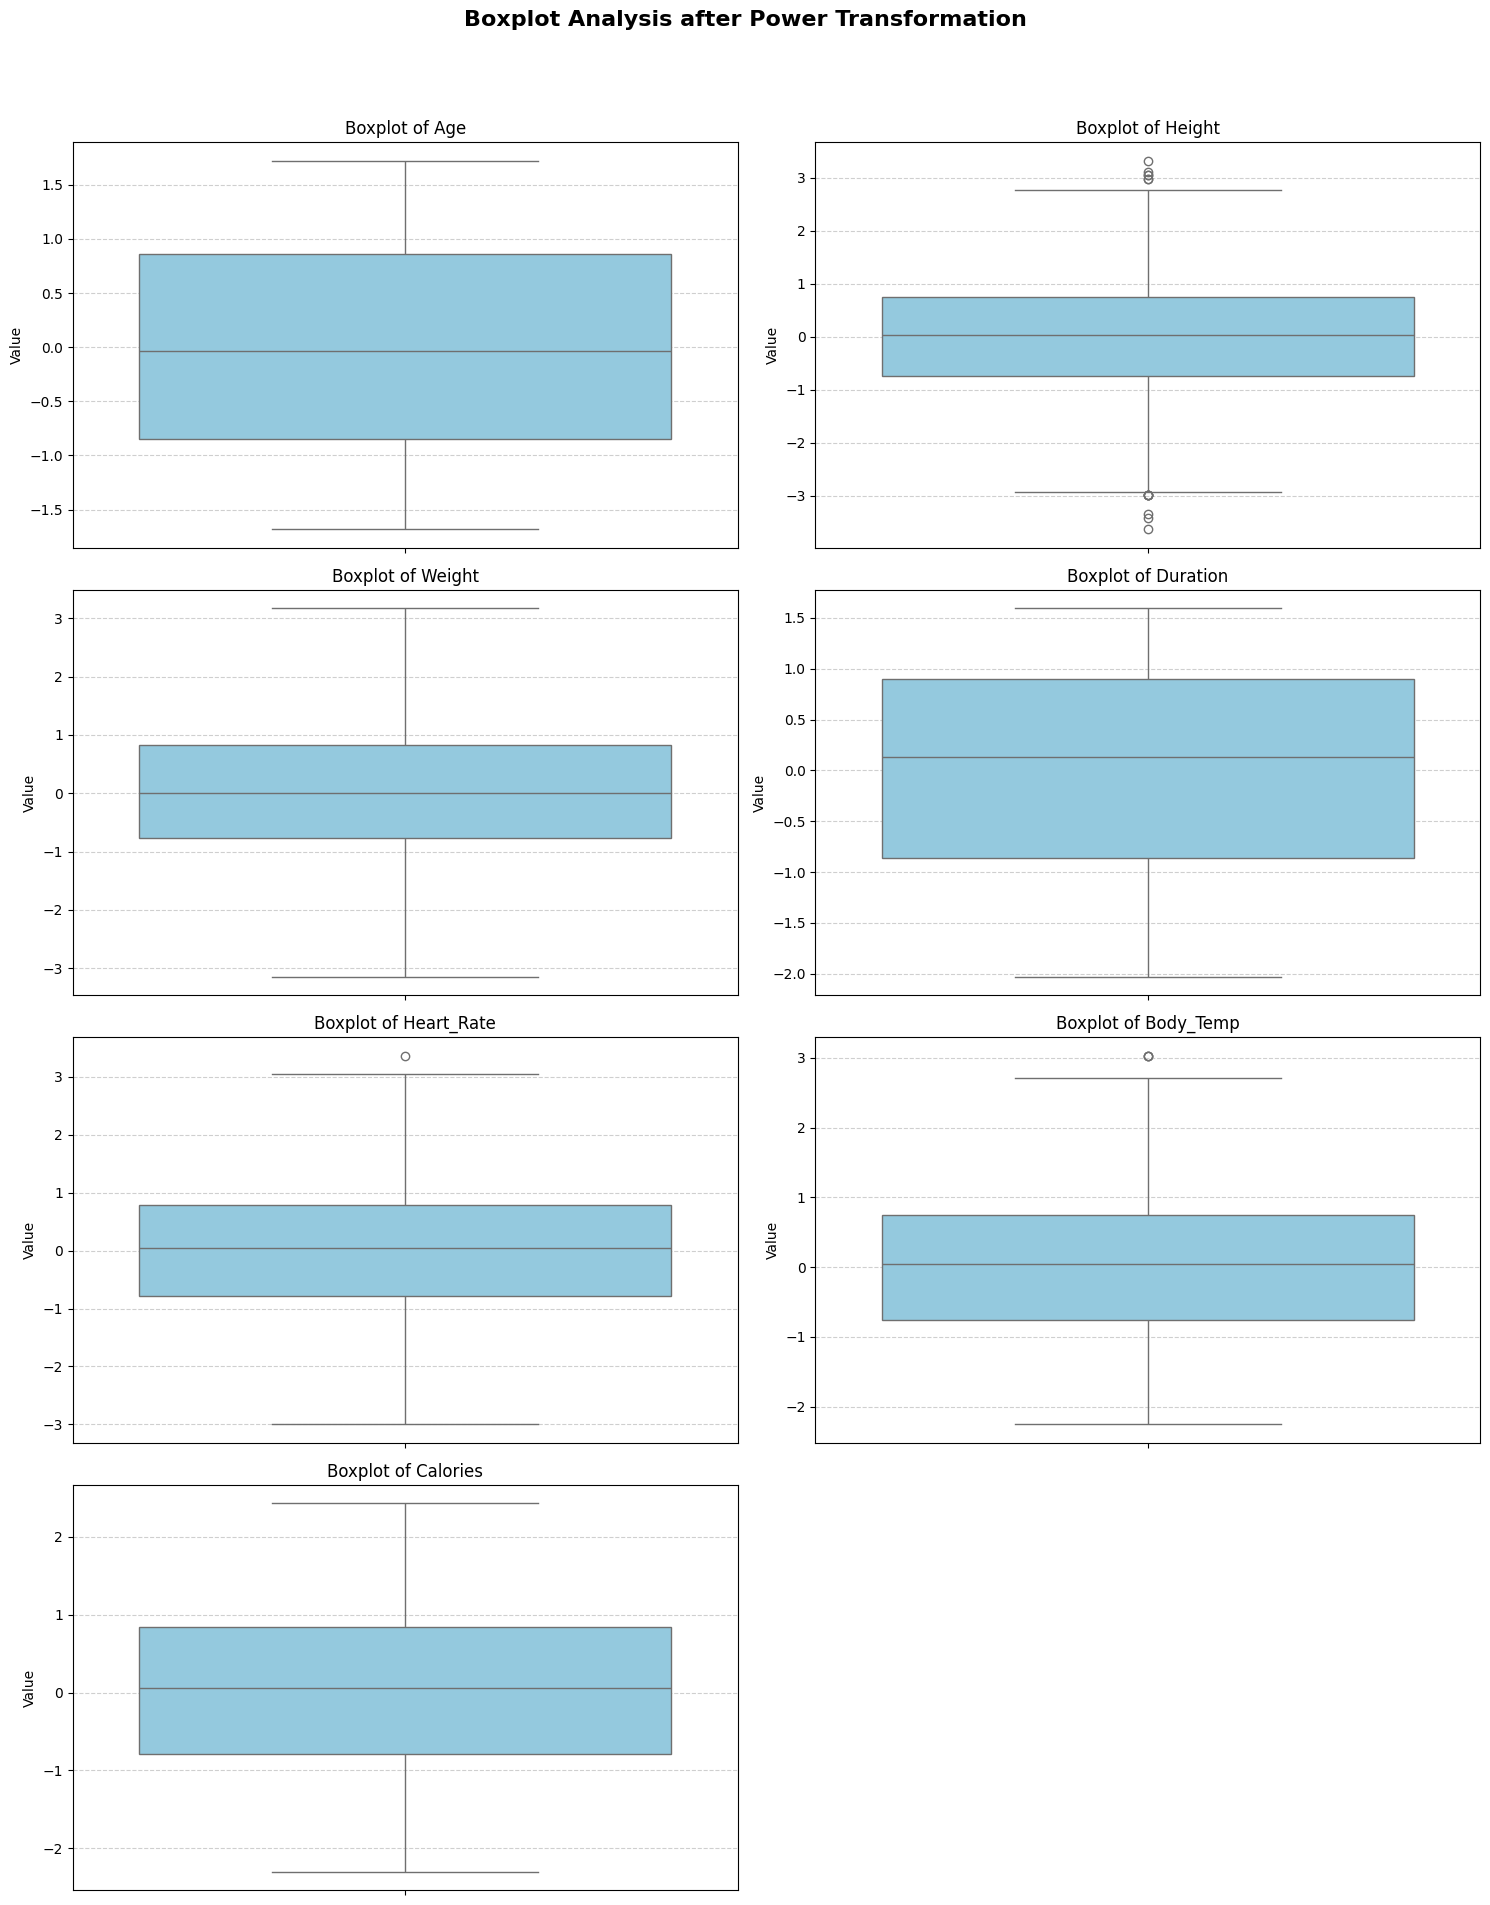

In [16]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
fig.suptitle('Boxplot Analysis after Power Transformation', fontsize=16, fontweight='bold')

axes = axes.flatten()

for i, item in enumerate(num_cols):
    sns.boxplot(y=data_bc[item], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {item}', fontsize=12)
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [17]:
num_outlier = count_outliers(data_bc,num_cols)
print("Percentage of outliers for each column (%)")
print(num_outlier)

Percentage of outliers for each column (%)
Age           0.000000
Height        0.093333
Weight        0.000000
Duration      0.000000
Heart_Rate    0.006667
Body_Temp     0.020000
Calories      0.000000
dtype: float64


In [18]:
data.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate',
       'Body_Temp', 'Calories'],
      dtype='object')

In [19]:
le = LabelEncoder()
data["Gender"] = le.fit_transform(data["Gender"])
df = data.copy()
df[num_cols] = data_bc.copy()
df_X = df.drop("Calories",axis=1)
df_y = df["Calories"]
train_X, test_X, train_y, test_y = train_test_split(df_X,df_y, test_size=0.3, shuffle=True)
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X)
test_X_scaled = scaler.transform(test_X)

In [20]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Ridge": Ridge()
}

In [21]:
performance_results = {}
predictions = {}

for name, model in models.items():
    model.fit(train_X_scaled, train_y)
    y_pred = model.predict(test_X_scaled)
    predictions[name] = y_pred

    mse = mean_squared_error(test_y, y_pred)
    mae = mean_absolute_error(test_y, y_pred)
    rmse = np.sqrt(mse)

    performance_results[name] = {
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse
    }

df_performance = pd.DataFrame(performance_results).T
print(df_performance)

                        MSE       MAE      RMSE
Linear Regression  0.010222  0.079266  0.101102
Random Forest      0.001874  0.029778  0.043290
KNN                0.007867  0.068920  0.088696
SVR                0.002109  0.035286  0.045921
Decision Tree      0.005553  0.052895  0.074522
XGBoost            0.000971  0.023593  0.031164
Gradient Boosting  0.002086  0.033910  0.045676
Ridge              0.010223  0.079270  0.101107


In [22]:
len(train_y)

10500

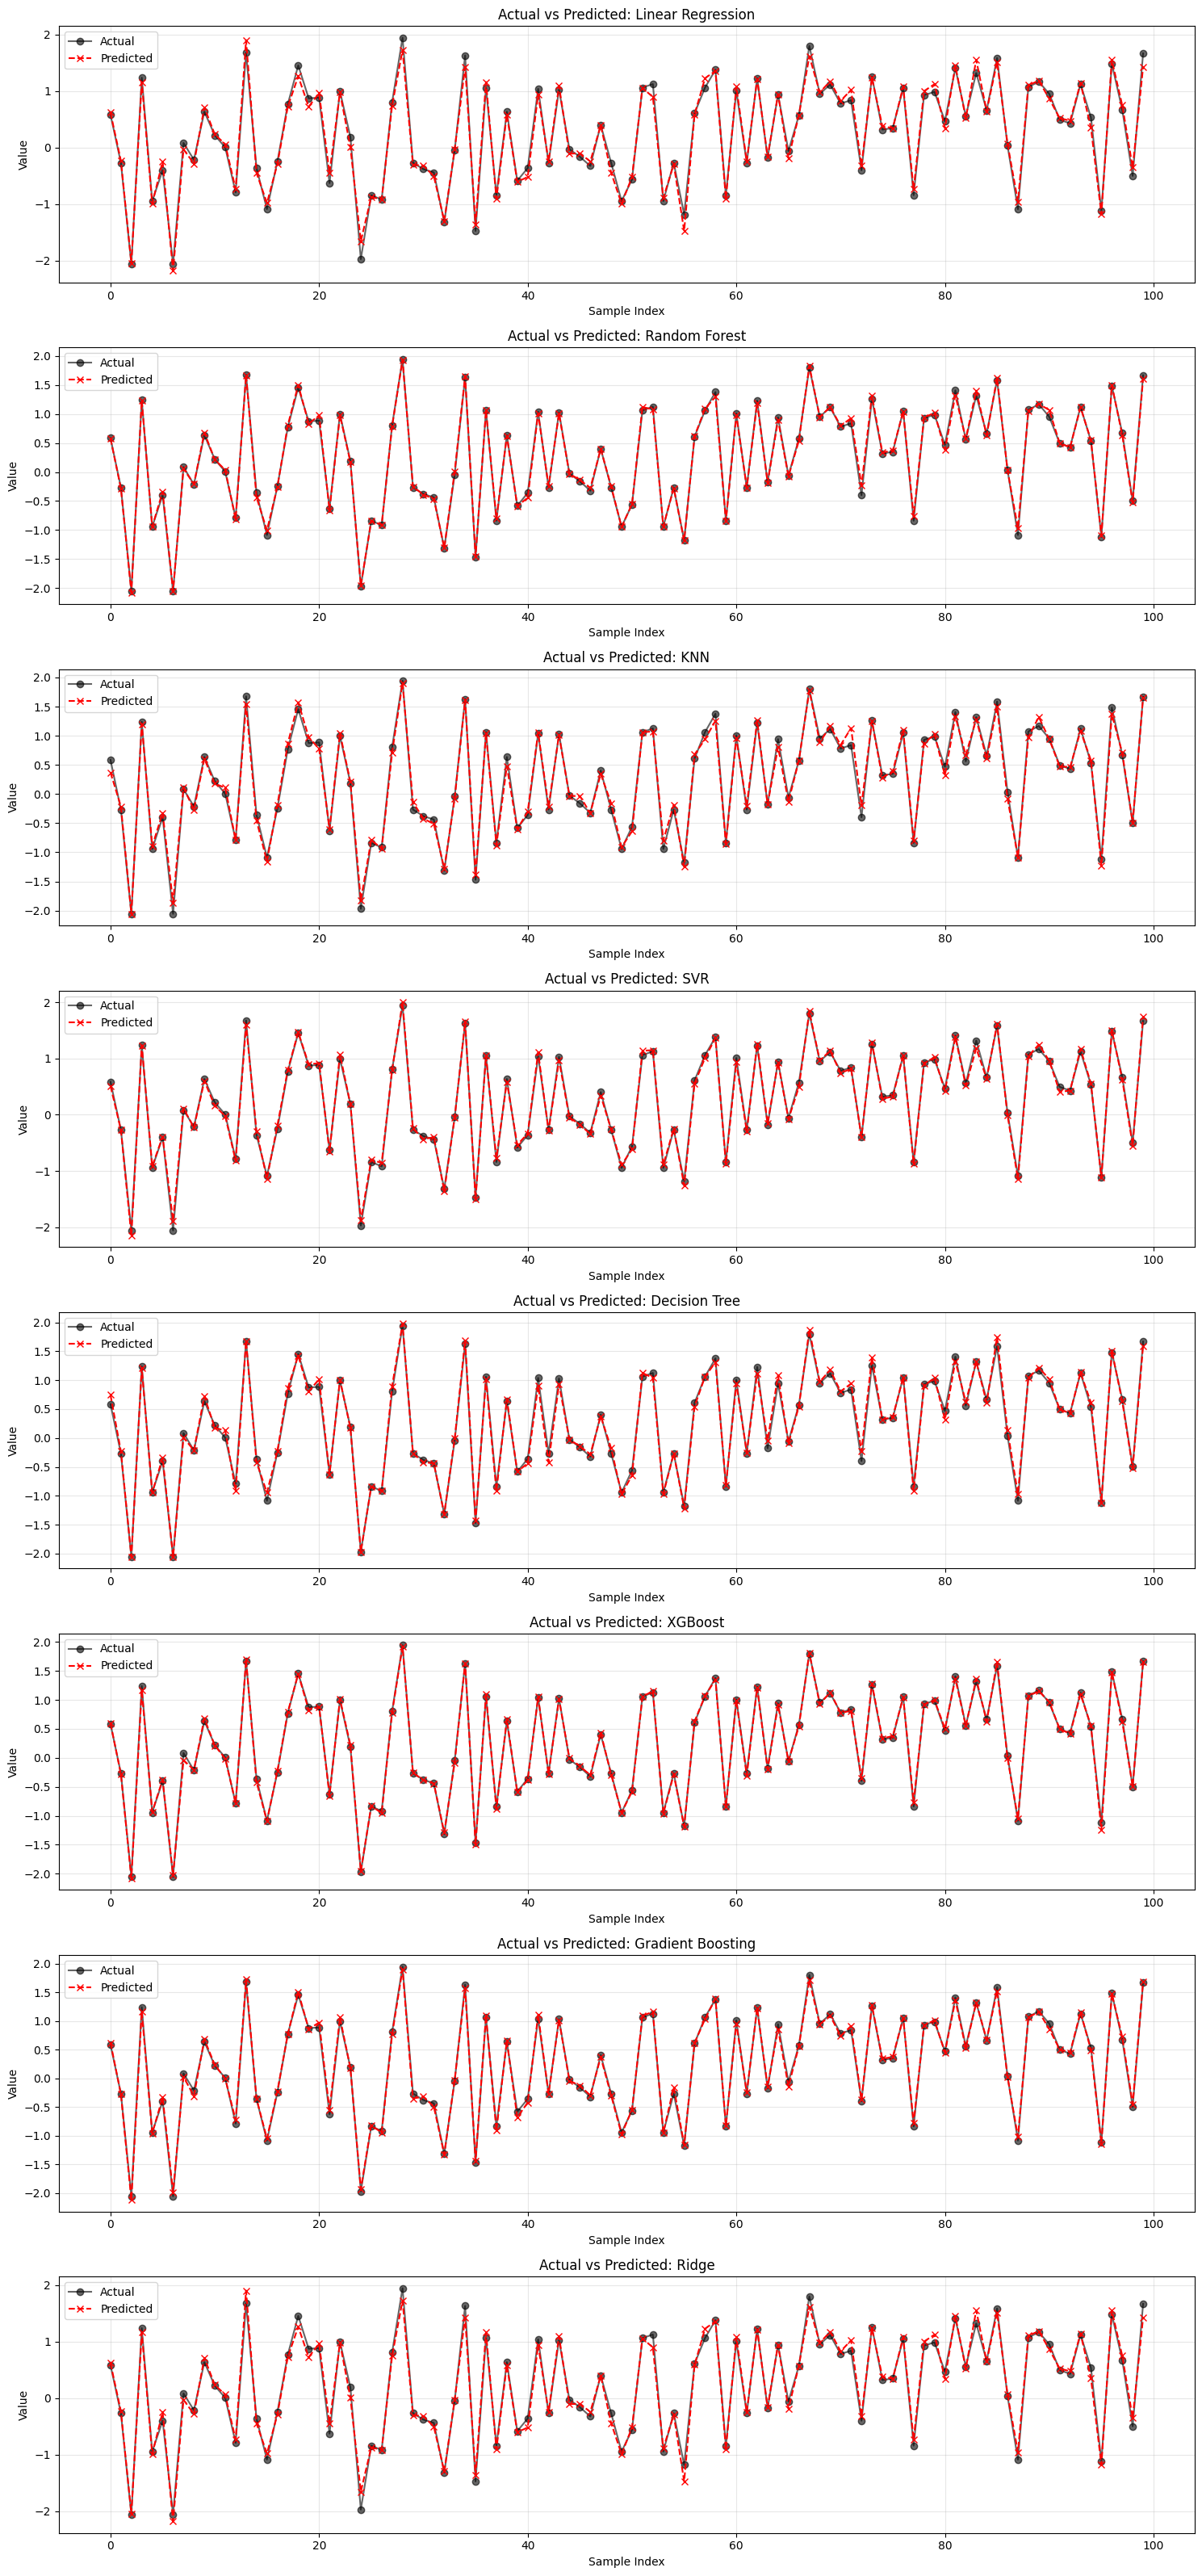

In [23]:
fig, axes = plt.subplots(len(models), 1, figsize=(15, 4 * len(models)))
samples = 100
x_axis = np.arange(samples)

for i, (name, y_pred) in enumerate(predictions.items()):
    axes[i].plot(x_axis, test_y[:samples], label='Actual', color='black', marker='o', alpha=0.6)
    axes[i].plot(x_axis, y_pred[:samples], label='Predicted', color='red', marker='x', linestyle='--')
    axes[i].set_title(f'Actual vs Predicted: {name}')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Value')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

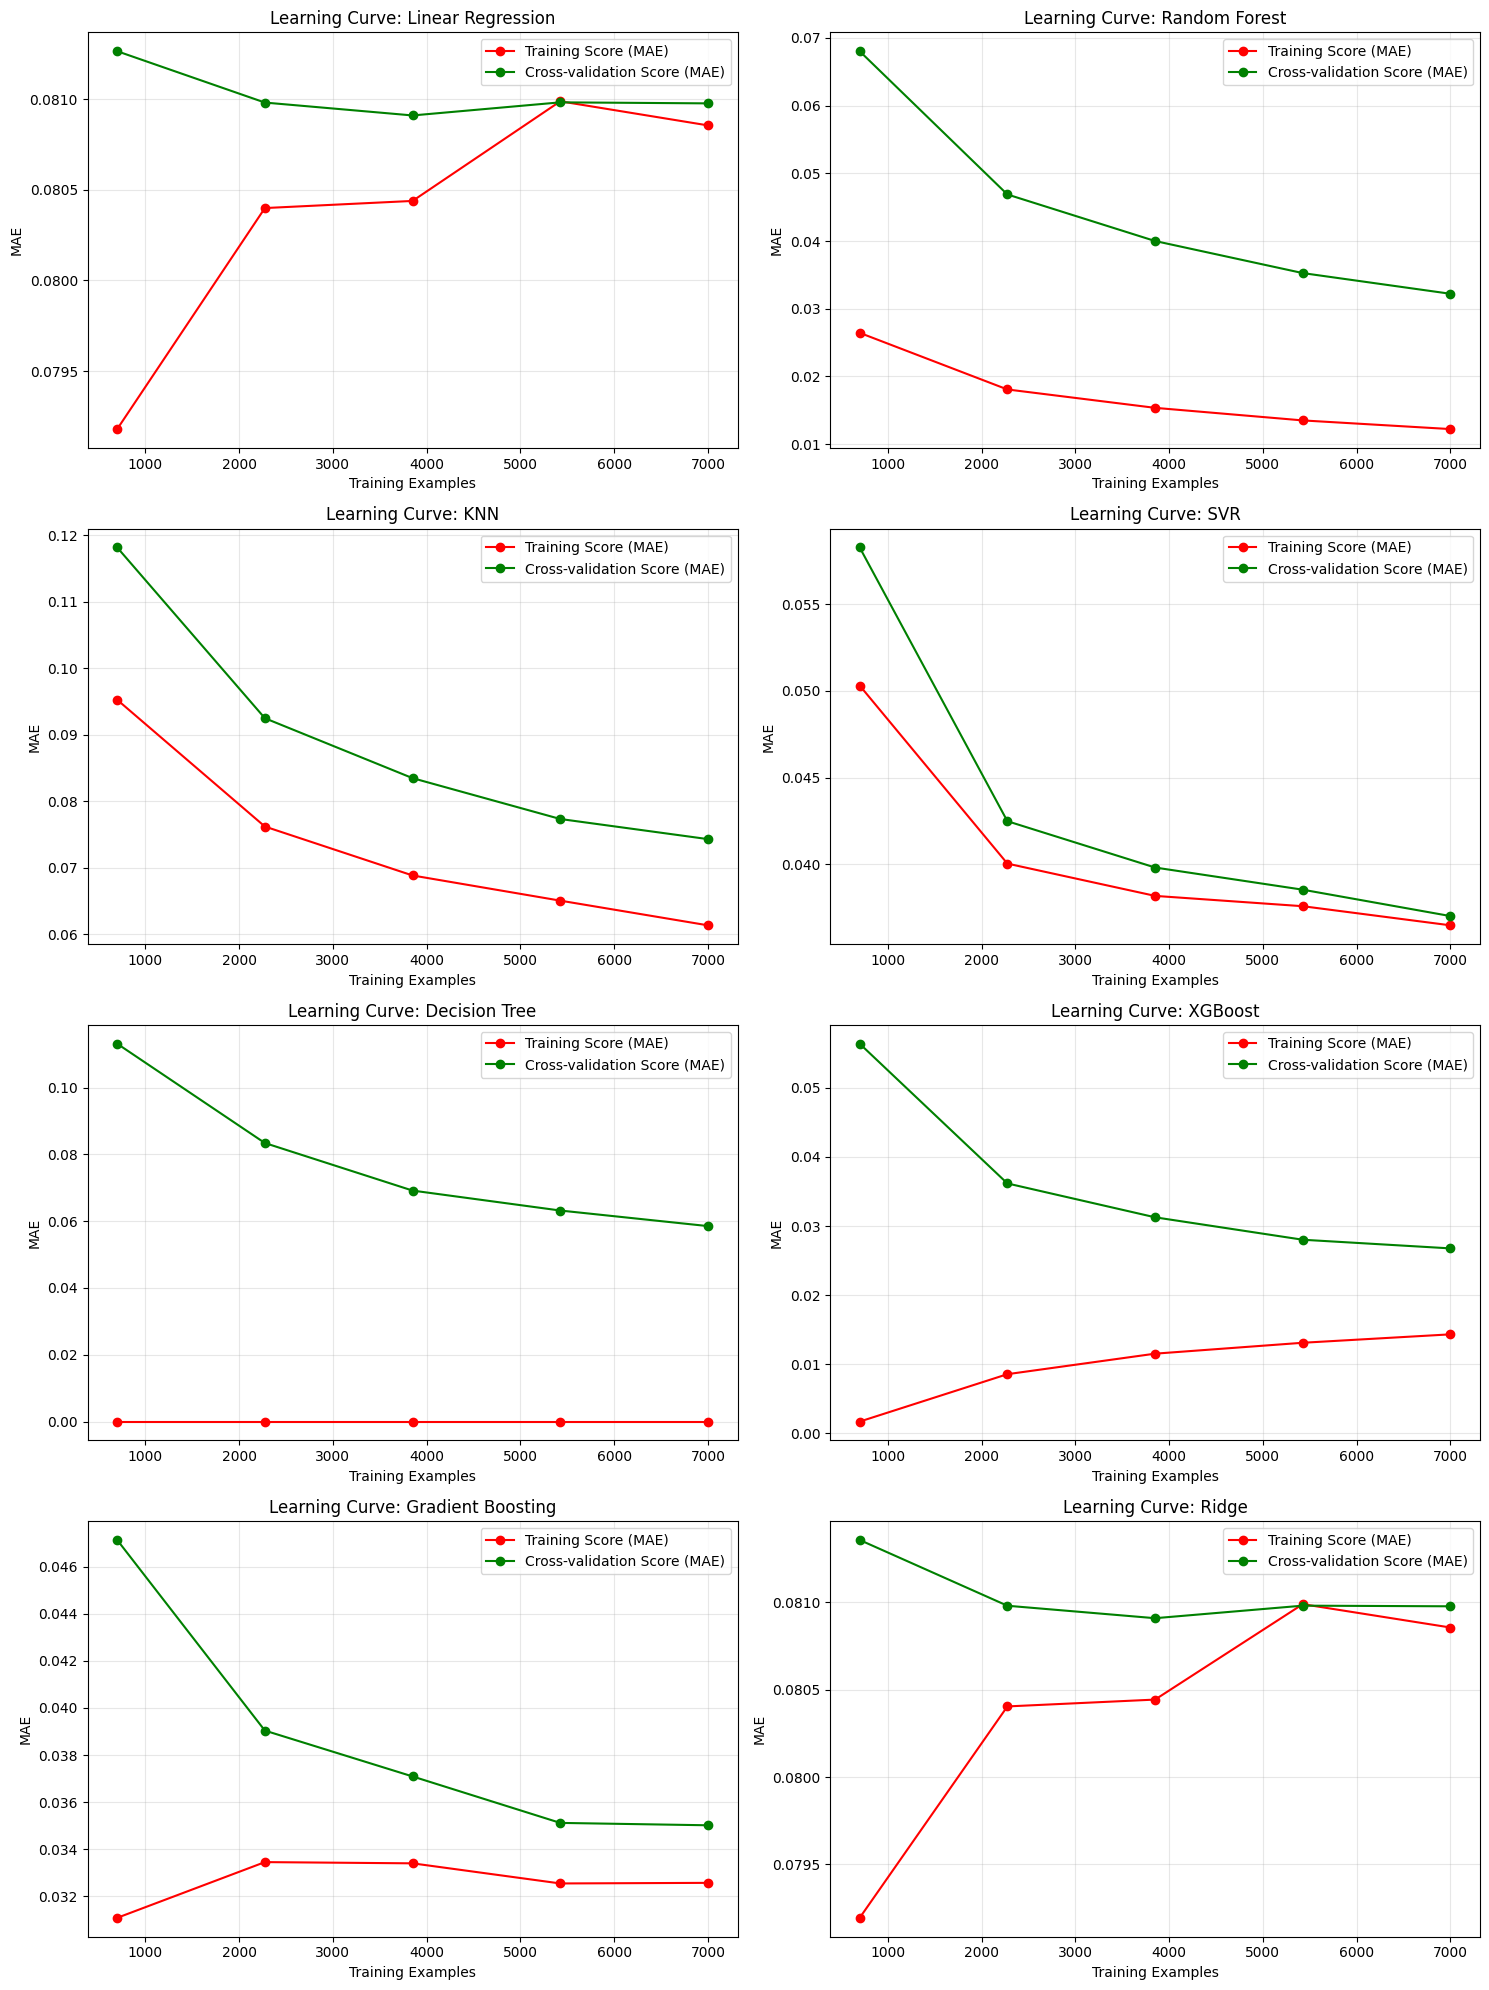

In [24]:
def plot_all_learning_curves(models, X, y):
    n_models = len(models)
    rows = (n_models + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(15, 5 * rows))
    axes = axes.flatten()

    for i, (name, model) in enumerate(models.items()):
        train_sizes, train_scores, test_scores = learning_curve(
            model, X, y, cv=3, n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 5),
            scoring='neg_mean_absolute_error')

        train_scores_mean = -np.mean(train_scores, axis=1)
        test_scores_mean = -np.mean(test_scores, axis=1)

        axes[i].plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Score (MAE)")
        axes[i].plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation Score (MAE)")

        axes[i].set_title(f"Learning Curve: {name}")
        axes[i].set_xlabel("Training Examples")
        axes[i].set_ylabel("MAE")
        axes[i].legend(loc="best")
        axes[i].grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_all_learning_curves(models, train_X_scaled, train_y)

In [28]:
import joblib

xgb_model = models["XGBoost"]
joblib.dump(xgb_model, 'xgb_model-calorie_prediction.pkl')

['xgb_model-calorie_prediction.pkl']

In [26]:
import pickle

baseline_distribution = {
    'transformers': {
        'powertransformer': pt,
        'labelencoder': le},
    'distributions': {},
    'features_metadata': {
        'num_cols': ["Age", "Height", "Weight", "Duration", "Heart_Rate", "Body_Temp"],
        'cat_cols': ["Gender"]}}
for col in df_X.columns:
    if col == "Gender":
        prob = df_X[col].value_counts(normalize=True).to_dict()
        baseline_distribution['distributions'][col] = {'type': 'categorical', 'data': prob}
    else:
        counts, bin_edges = np.histogram(df_X[col], bins=15, density=True)
        prob = (counts + 1e-10) / (np.sum(counts + 1e-10))
        baseline_distribution['distributions'][col] = {
            'type': 'numeric',
            'prob': prob,
            'bins': bin_edges}

with open('baseline_distribution.pkl', 'wb') as f:
    pickle.dump(baseline_distribution, f)

In [27]:
import sqlite3
conn = sqlite3.connect('SQLite_calorie.db')
cursor = conn.cursor()

cursor.execute('''
    CREATE TABLE IF NOT EXISTS user_logs (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        timestamp DATETIME DEFAULT CURRENT_TIMESTAMP,
        gender INTEGER,
        age FLOAT,
        height FLOAT,
        weight FLOAT,
        duration FLOAT,
        predicted_calories FLOAT)
''')

conn.commit()
conn.close()